In [1]:
#%pip install -r requirements.txt


In [2]:
from utils import *

In [3]:
from flwr_datasets import FederatedDataset
from flwr_datasets.partitioner import IidPartitioner
from torchvision import transforms
from torch.utils.data import random_split
from torch import tensor


/Users/parulpandey/Desktop/Fed_learn/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# ---------- transform ----------
transforms = transforms.ToTensor()

def apply_transforms(batch):
    batch["image"] = [transforms(img) for img in batch["image"]]
    return batch

In [5]:
partitioner = IidPartitioner(num_partitions=1)

fds = FederatedDataset(
    dataset="ylecun/mnist",
    partitioners={"train": partitioner},
)




In [6]:
trainset = fds.load_partition(0)
trainset = trainset.with_transform(apply_transforms)

In [7]:
# load full training split
#partition = fds.load_partition(0, "train")

In [8]:
total_length = len(trainset)
split_size = total_length // 3

torch.manual_seed(42)
part1, part2, part3 = random_split(trainset, [split_size] * 3)


In [9]:
train_loader_1 = DataLoader(part1, batch_size=64, shuffle=True)
train_loader_2 = DataLoader(part2, batch_size=64, shuffle=True)
train_loader_3 = DataLoader(part3, batch_size=64, shuffle=True)



In [10]:
part1 = exclude_digits(part1, excluded_digits=[1, 3, 7])
part2 = exclude_digits(part2, excluded_digits=[2, 5, 8])
part3 = exclude_digits(part3, excluded_digits=[4, 6, 9])


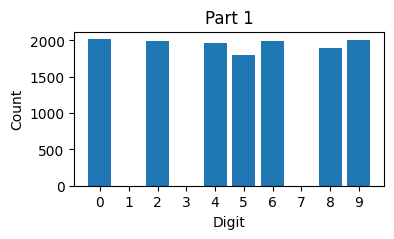

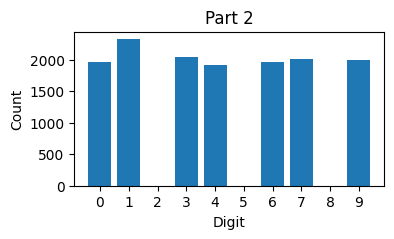

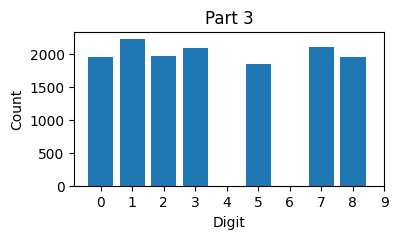

In [11]:
plot_distribution(part1, "Part 1")
plot_distribution(part2, "Part 2")
plot_distribution(part3, "Part 3")

Epoch 1: Loss = 0.7177944163852763
Epoch 2: Loss = 0.2797135546385685
Epoch 3: Loss = 0.23344228016299623
Epoch 4: Loss = 0.20387227380665662
Epoch 5: Loss = 0.18012451237746488
Epoch 6: Loss = 0.1616363810880162
Epoch 7: Loss = 0.14394975523246784
Epoch 8: Loss = 0.13025760272883366
Epoch 9: Loss = 0.11779772090751713
Epoch 10: Loss = 0.10729916331088432
Training complete


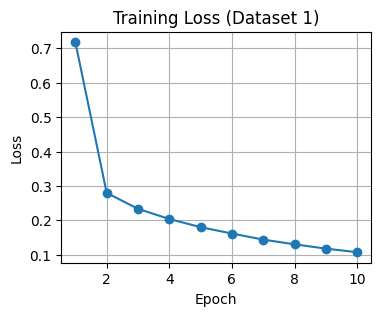

Epoch 1: Loss = 0.5807642801727415
Epoch 2: Loss = 0.19090383850672854
Epoch 3: Loss = 0.1593975767142436
Epoch 4: Loss = 0.14324339559393615
Epoch 5: Loss = 0.13048245483850685
Epoch 6: Loss = 0.12011870554744396
Epoch 7: Loss = 0.11246901520866183
Epoch 8: Loss = 0.10289644380622114
Epoch 9: Loss = 0.09711797079363746
Epoch 10: Loss = 0.09057316212025325
Training complete


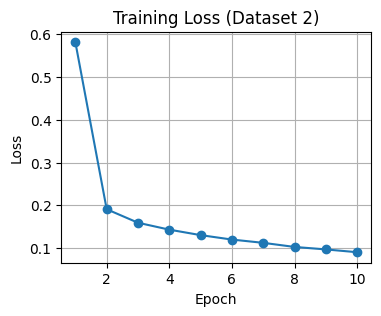

Epoch 1: Loss = 0.6981493393085662
Epoch 2: Loss = 0.28576341881606376
Epoch 3: Loss = 0.23960679371702184
Epoch 4: Loss = 0.21159085786450502
Epoch 5: Loss = 0.18920295419196737
Epoch 6: Loss = 0.16785965534559202
Epoch 7: Loss = 0.1495493759160937
Epoch 8: Loss = 0.13495512726417494
Epoch 9: Loss = 0.1221692656668333
Epoch 10: Loss = 0.11270756736330317
Training complete


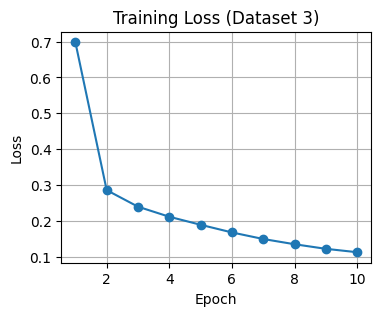

In [12]:
model1 = SimpleModel()
losses_1 = train_model(model1, part1)
plot_loss_curve(losses_1, "Training Loss (Dataset 1)")

model2 = SimpleModel()
losses_2 = train_model(model2, part2)
plot_loss_curve(losses_2, "Training Loss (Dataset 2)")

model3 = SimpleModel()
losses_3 = train_model(model3, part3)
plot_loss_curve(losses_3, "Training Loss (Dataset 3)")

In [13]:
# Load test data from Flower MNIST
testset = fds.load_split("test")
testset = testset.with_transform(apply_transforms)

In [14]:
len(testset)

10000

In [15]:

testset_137 = include_digits(testset, included_digits=[1, 3, 7])
testset_258 = include_digits(testset, included_digits=[2, 5, 8])
testset_469 = include_digits(testset, included_digits=[4, 6, 9])

In [16]:
_, accuracy1 = evaluate_model(model1, testset)
_, accuracy1_on_137 = evaluate_model(model1, testset_137)
print(
    f"Model 1-> Test Accuracy on all digits: {accuracy1:.4f}, "
    f"Test Accuracy on [1,3,7]: {accuracy1_on_137:.4f}"
)

_, accuracy2 = evaluate_model(model2, testset)
_, accuracy2_on_258 = evaluate_model(model2, testset_258)
print(
    f"Model 2-> Test Accuracy on all digits: {accuracy2:.4f}, "
    f"Test Accuracy on [2,5,8]: {accuracy2_on_258:.4f}"
)

_, accuracy3 = evaluate_model(model3, testset)
_, accuracy3_on_469 = evaluate_model(model3, testset_469)
print(
    f"Model 3-> Test Accuracy on all digits: {accuracy3:.4f}, "
    f"Test Accuracy on [4,6,9]: {accuracy3_on_469:.4f}"
)

Model 1-> Test Accuracy on all digits: 0.6522, Test Accuracy on [1,3,7]: 0.0000
Model 2-> Test Accuracy on all digits: 0.6859, Test Accuracy on [2,5,8]: 0.0000
Model 3-> Test Accuracy on all digits: 0.6780, Test Accuracy on [4,6,9]: 0.0000


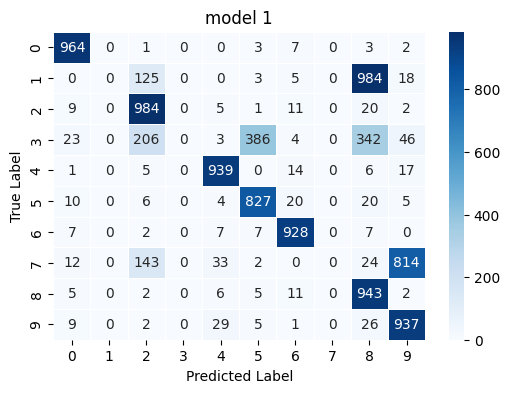

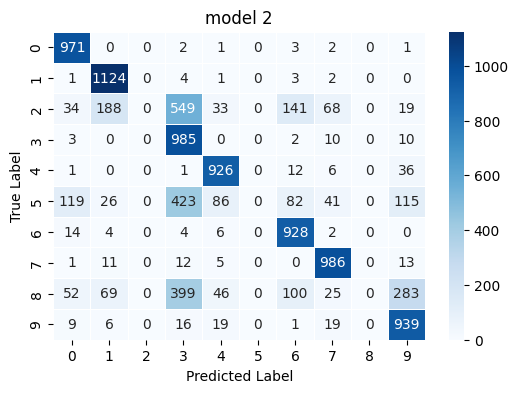

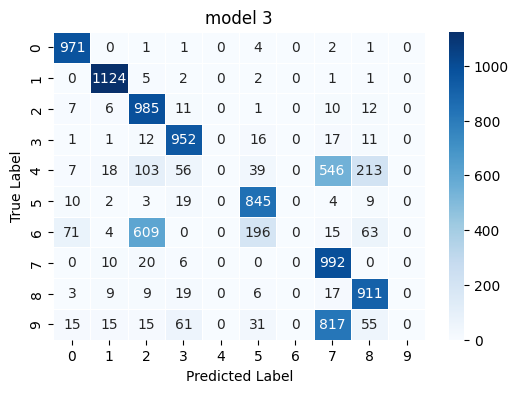

In [17]:
confusion_matrix_model1_all = compute_confusion_matrix(model1, testset)
confusion_matrix_model2_all = compute_confusion_matrix(model2, testset)
confusion_matrix_model3_all = compute_confusion_matrix(model3, testset)

plot_confusion_matrix(confusion_matrix_model1_all, "model 1")
plot_confusion_matrix(confusion_matrix_model2_all, "model 2")
plot_confusion_matrix(confusion_matrix_model3_all, "model 3")




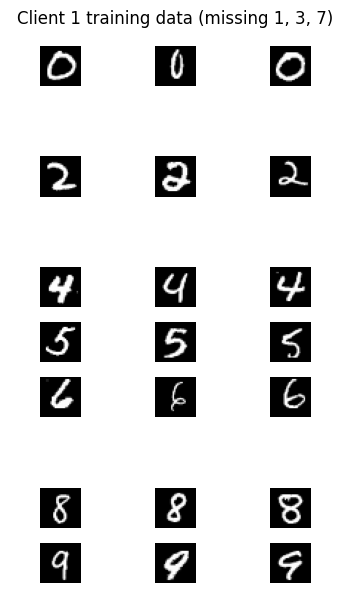

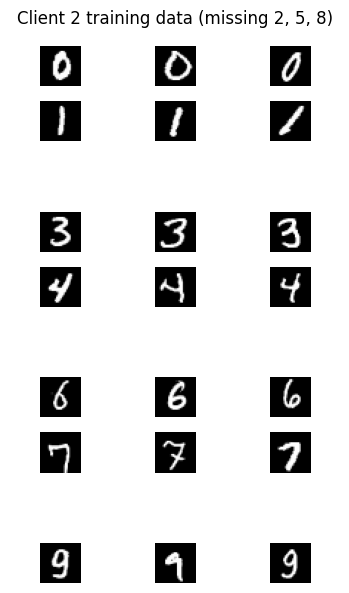

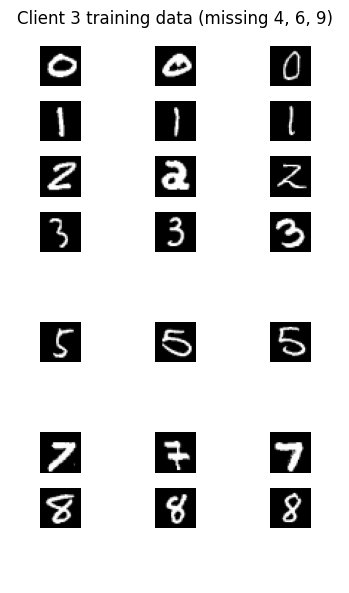

In [18]:
show_training_samples(part1, "Client 1 training data (missing 1, 3, 7)")
show_training_samples(part2, "Client 2 training data (missing 2, 5, 8)")
show_training_samples(part3, "Client 3 training data (missing 4, 6, 9)")


In [23]:
def plot_confusion_matrix_with_missing(cm, title, missing_digits):
    # Normalize per true label and convert to percentage
    cm_pct = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    cm_pct = np.nan_to_num(cm_pct) * 100

    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(
        cm_pct,
        annot=True,
        fmt=".1f",
        cmap="Greys",
        cbar=True,
        linewidths=0.5,
        linecolor="lightgray",
        vmin=0,
        vmax=100
    )

    # Highlight rows for missing digits with background shading
    for d in missing_digits:
        ax.axhspan(d, d + 1, color="#f0e6d6", alpha=0.6)

    ax.set_title(
        f"{title}\nRows = true digit, columns = predicted digit (values in %)",
        fontsize=12,
        pad=12
    )
    ax.set_xlabel("Predicted digit")
    ax.set_ylabel("True digit")

    # Inline explanation
    plt.text(
        0.5,
        -0.18,
        "Shaded rows correspond to digits missing during training.\n"
        "Each row sums to 100%, showing where predictions are sent.",
        ha="center",
        va="center",
        transform=ax.transAxes,
        fontsize=10
    )

    plt.tight_layout()
    plt.show()


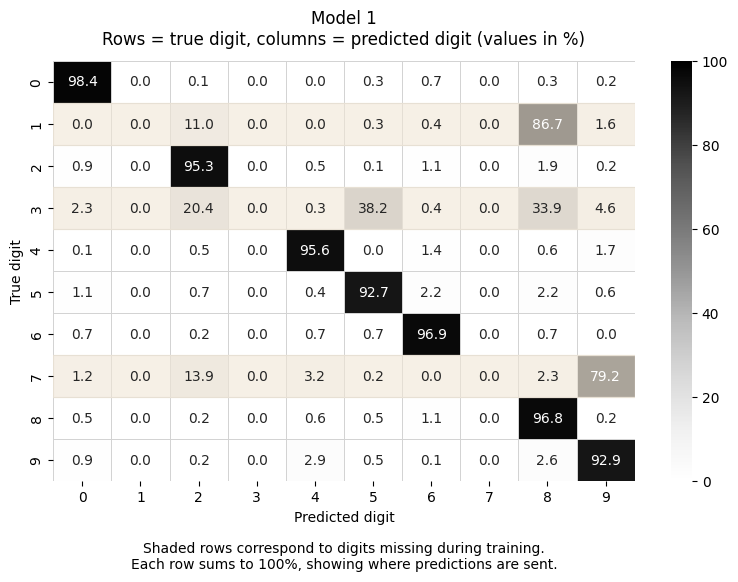

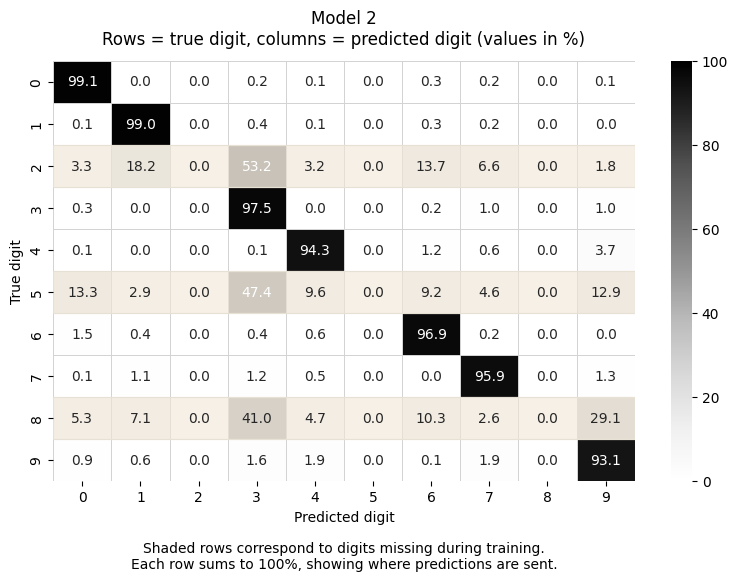

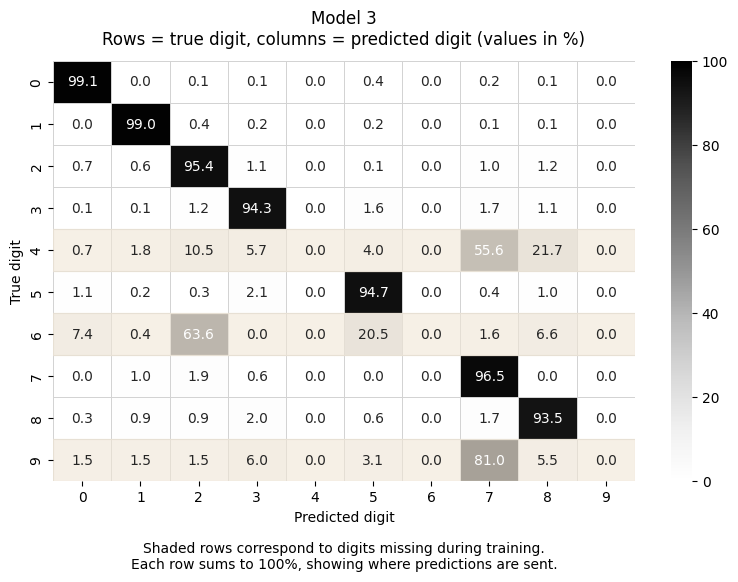

In [24]:
plot_confusion_matrix_with_missing(
    confusion_matrix_model1_all,
    "Model 1",
    missing_digits=[1, 3, 7]
)

plot_confusion_matrix_with_missing(
    confusion_matrix_model2_all,
    "Model 2",
    missing_digits=[2, 5, 8]
)

plot_confusion_matrix_with_missing(
    confusion_matrix_model3_all,
    "Model 3",
    missing_digits=[4, 6, 9]
)
